This notebook prepares the VizWiz-Captions validation set for image captioning.
It downloads/loads images and annotations, cleans captions, builds a vocabulary,
creates train/validation/test splits, and defines reusable PyTorch datasets and dataloaders.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import random
import numpy as np
import torch

RANDOM_SEED = 42

random.seed(RANDOM_SEED)           # Python built-in random
np.random.seed(RANDOM_SEED)        # NumPy operations
torch.manual_seed(RANDOM_SEED)     # PyTorch CPU operations

# GPU seed — ensures reproducibility if a CUDA device is available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"✅ Global random seed set to {RANDOM_SEED}")
print(f"   Python random | NumPy | PyTorch CPU | PyTorch GPU (if available)")

✅ Global random seed set to 42
   Python random | NumPy | PyTorch CPU | PyTorch GPU (if available)


In [3]:
import json

file_path = '/content/drive/MyDrive/DL AT3/annotations/annotations/test.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
    print("JSON data loaded successfully:")
    # Display the first few items or a summary if the data is very large
    if isinstance(data, list):
        print(f"Number of items: {len(data)}")
        if len(data) > 5:
            print("First 5 items (pretty-printed):")
            for i in range(5):
                print(json.dumps(data[i], indent=2))
        else:
            print("Full list data (pretty-printed):")
            print(json.dumps(data, indent=2))
    elif isinstance(data, dict):
        print("Dictionary data (pretty-printed):")
        print(json.dumps(data, indent=2))
    else:
        print("Other data type (pretty-printed):")
        print(json.dumps(data, indent=2))
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please check the path.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from the file at {file_path}. Please check the file content.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

JSON data loaded successfully:
Dictionary data (pretty-printed):
{
  "info": {
    "description": "This dataset contains crowdsourced captions of images from VizWiz datasets. This file contains the test partition.",
    "license": {
      "url": "https://creativecommons.org/licenses/by/4.0/",
      "name": "Attribution 4.0 International (CC BY 4.0)"
    },
    "url": "https://vizwiz.org",
    "version": "VizWiz-Captions 1.0",
    "year": 2019,
    "contributor": "VizWiz-Captions Consortium",
    "date_created": "2019-12-23"
  },
  "images": [
    {
      "file_name": "VizWiz_test_00000000.jpg",
      "vizwiz_url": "https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_test_00000000.jpg",
      "id": 31181,
      "text_detected": true
    },
    {
      "file_name": "VizWiz_test_00000001.jpg",
      "vizwiz_url": "https://ivc.ischool.utexas.edu/VizWiz_visualization_img/VizWiz_test_00000001.jpg",
      "id": 31182,
      "text_detected": false
    },
    {
      "file_name": "Vi

In [ ]:
import json

file_path = '/content/drive/MyDrive/DL AT3/annotations/annotations/train.json'

print(f"\n--- Loading {file_path.split('/')[-1]} ---")
try:
    with open(file_path, 'r') as f:
        data_train = json.load(f)
    print("JSON data loaded successfully:")
    if isinstance(data_train, list):
        print(f"Number of items: {len(data_train)}")
        if len(data_train) > 5:
            print("First 5 items (pretty-printed):")
            for i in range(5):
                print(json.dumps(data_train[i], indent=2))
        else:
            print("Full list data (pretty-printed):")
            print(json.dumps(data_train, indent=2))
    elif isinstance(data_train, dict):
        print("Dictionary data (pretty-printed):")
        print(json.dumps(data_train, indent=2))
    else:
        print("Other data type (pretty-printed):")
        print(json.dumps(data_train, indent=2))
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please check the path.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from the file at {file_path}. Please check the file content.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Loading train.json ---
JSON data loaded successfully:
Dictionary data (pretty-printed):


In [ ]:
import json

file_path = '/content/drive/MyDrive/DL AT3/annotations/annotations/val.json'

print(f"\n--- Loading {file_path.split('/')[-1]} ---")
try:
    with open(file_path, 'r') as f:
        data_val = json.load(f)
    print("JSON data loaded successfully:")
    if isinstance(data_val, list):
        print(f"Number of items: {len(data_val)}")
        if len(data_val) > 5:
            print("First 5 items (pretty-printed):")
            for i in range(5):
                print(json.dumps(data_val[i], indent=2))
        else:
            print("Full list data (pretty-printed):")
            print(json.dumps(data_val, indent=2))
    elif isinstance(data_val, dict):
        print("Dictionary data (pretty-printed):")
        print(json.dumps(data_val, indent=2))
    else:
        print("Other data type (pretty-printed):")
        print(json.dumps(data_val, indent=2))
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please check the path.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from the file at {file_path}. Please check the file content.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
import os

# Define the folder path you want to inspect
folder_path = '/content/drive/MyDrive/DL AT3/val/val'

file_types = set() # Use a set to store unique file types

print(f"\n--- Analyzing folder: {folder_path} ---")

try:
    # List all entries in the directory
    for entry_name in os.listdir(folder_path):
        full_path = os.path.join(folder_path, entry_name)

        # Check if it's a file (not a directory)
        if os.path.isfile(full_path):
            # Get the file extension
            _, extension = os.path.splitext(entry_name)

            # Add the extension to our set (remove the leading dot if present and convert to lowercase)
            if extension:
                file_types.add(extension.lstrip('.').lower())

    if file_types:
        print("Unique file types found:")
        for file_type in sorted(list(file_types)): # Sort for consistent output
            print(f"- {file_type}")
    else:
        print("No files with extensions found in the specified folder.")

except FileNotFoundError:
    print(f"Error: The folder at {folder_path} was not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Analyzing folder: /content/drive/MyDrive/DL AT3/val/val ---
Unique file types found:
- jpg


In [ ]:
import os

folder_path = '/content/drive/MyDrive/DL AT3/val/val'

print(f"\n--- Listing some file names from: {folder_path} ---")
try:
    # Get all entries in the directory
    all_entries = os.listdir(folder_path)

    # Filter for files only (optional, but good practice if directories are mixed in)
    file_names = [entry for entry in all_entries if os.path.isfile(os.path.join(folder_path, entry))]

    if file_names:
        print(f"Found {len(file_names)} files. Displaying the first 10 file names:")
        for i, file_name in enumerate(file_names[:10]): # Display up to the first 10 file names
            print(f"- {file_name}")
    else:
        print("No files found in the specified folder.")

except FileNotFoundError:
    print(f"Error: The folder at {folder_path} was not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Listing some file names from: /content/drive/MyDrive/DL AT3/val/val ---
Found 7750 files. Displaying the first 10 file names:
- VizWiz_val_00006702.jpg
- VizWiz_val_00006844.jpg
- VizWiz_val_00006750.jpg
- VizWiz_val_00006654.jpg
- VizWiz_val_00006716.jpg
- VizWiz_val_00006658.jpg
- VizWiz_val_00006865.jpg
- VizWiz_val_00006783.jpg
- VizWiz_val_00006885.jpg
- VizWiz_val_00006753.jpg


In [ ]:
# Inspecting the number of items in each JSON dataset

print("\n--- Annotation Details ---")

# For test.json (data variable)
if 'images' in data and isinstance(data['images'], list):
    print(f"Test data (test.json) has {len(data['images'])} images.")
else:
    print("Test data (test.json) does not contain an 'images' list or it's not in the expected format.")

# For train.json (data_train variable)
if 'annotations' in data_train and isinstance(data_train['annotations'], list):
    print(f"Train data (train.json) has {len(data_train['annotations'])} annotations.")
else:
    print("Train data (train.json) does not contain an 'annotations' list or it's not in the expected format.")

# For val.json (data_val variable)
if 'annotations' in data_val and isinstance(data_val['annotations'], list):
    print(f"Validation data (val.json) has {len(data_val['annotations'])} annotations.")
else:
    print("Validation data (val.json) does not contain an 'annotations' list or it's not in the expected format.")


--- Annotation Details ---
Test data (test.json) has 8000 images.
Train data (train.json) has 117155 annotations.
Validation data (val.json) has 38750 annotations.


## Data Preprocessing for VizWiz-Captions Validation Set

This section of the notebook focuses on preparing the VizWiz-Captions validation dataset for an image captioning task. The steps include loading annotation JSON files, reading image filenames from disk, ensuring consistency between the JSON and disk files, merging image and annotation data, filtering out invalid captions, and finally splitting the dataset into internal training, validation, and testing subsets based on `image_id` to prevent data leakage.

In [ ]:
import os
import json
import pandas as pd
from sklearn.model_selection import train_test_split

# --- 1. Load paths ---
# Define relevant paths. Make sure these match your Google Drive structure.
VAL_DIR = '/content/drive/MyDrive/DL AT3/val/val'
VAL_JSON = '/content/drive/MyDrive/DL AT3/annotations/annotations/val.json'
OUT_DIR = '/content/drive/MyDrive/DL AT3/processed_data'

# Create output directory if it doesn't exist
os.makedirs(OUT_DIR, exist_ok=True)

print(f"VAL_DIR: {VAL_DIR}")
print(f"VAL_JSON: {VAL_JSON}")
print(f"OUT_DIR: {OUT_DIR}")

VAL_DIR: /content/drive/MyDrive/DL AT3/val/val
VAL_JSON: /content/drive/MyDrive/DL AT3/annotations/annotations/val.json
OUT_DIR: /content/drive/MyDrive/DL AT3/processed_data


In [ ]:
# --- 2. Load val.json and convert to pandas DataFrames ---
print(f"\n--- Loading {os.path.basename(VAL_JSON)} ---")
try:
    with open(VAL_JSON, 'r') as f:
        val_data = json.load(f)

    # Extract images and annotations
    raw_images_list = val_data['images']
    raw_annotations_list = val_data['annotations']

    # Convert to DataFrames
    images_df = pd.DataFrame(raw_images_list)
    annotations_df = pd.DataFrame(raw_annotations_list)

    print("val.json loaded successfully.")
    print(f"Original images_df shape: {images_df.shape}")
    print(f"Original annotations_df shape: {annotations_df.shape}")

    print("\nFirst 5 rows of images_df:")
    display(images_df.head())
    print("\nFirst 5 rows of annotations_df:")
    display(annotations_df.head())

except FileNotFoundError:
    print(f"Error: The val.json file at {VAL_JSON} was not found. Please check the path.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {VAL_JSON}. Please check its content.")
except KeyError as e:
    print(f"Error: Missing expected key in val.json: {e}")
except Exception as e:
    print(f"An unexpected error occurred while loading val.json: {e}")


--- Loading val.json ---
val.json loaded successfully.
Original images_df shape: (7750, 4)
Original annotations_df shape: (38750, 6)

First 5 rows of images_df:


,file_name,vizwiz_url,id,text_detected
0,VizWiz_val_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23431,True
1,VizWiz_val_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23432,True
2,VizWiz_val_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23433,True
3,VizWiz_val_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23434,True
4,VizWiz_val_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23435,True



First 5 rows of annotations_df:


,caption,image_id,is_precanned,is_rejected,id,text_detected
0,A computer screen shows a repair prompt on the...,23431,False,False,117155,True
1,a computer screen with a repair automatically ...,23431,False,False,117156,True
2,partial computer screen showing the need of re...,23431,False,False,117157,True
3,Part of a computer monitor showing a computer ...,23431,False,False,117158,True
4,The top of a laptop with a blue background and...,23431,False,False,117159,True


In [ ]:
# --- 3. Read image filenames from the VAL folder ---
print(f"\n--- Reading image filenames from {VAL_DIR} ---")
try:
    disk_image_files = [f for f in os.listdir(VAL_DIR) if f.endswith('.jpg')]
    disk_image_files_set = set(disk_image_files)
    print(f"Found {len(disk_image_files)} .jpg files on disk.")

except FileNotFoundError:
    print(f"Error: The image directory at {VAL_DIR} was not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred while reading image files: {e}")


--- Reading image filenames from /content/drive/MyDrive/DL AT3/val/val ---
Found 7750 .jpg files on disk.


In [ ]:
# --- 4. Verify image–JSON consistency ---
print("\n--- Verifying image–JSON consistency ---")

# Number of files on disk
total_disk_files = len(disk_image_files_set)
print(f"Total disk files (VAL_DIR): {total_disk_files}")

# Number of image records in JSON
total_json_image_records = len(images_df)
print(f"Total JSON image records (val.json): {total_json_image_records}")

# Filenames in JSON
json_filenames_set = set(images_df['file_name'].unique())

# Missing files on disk (present in JSON but not on disk)
missing_on_disk = json_filenames_set - disk_image_files_set
print(f"Missing files on disk (in JSON, not on disk): {len(missing_on_disk)}")
# if missing_on_disk: print(f"  Examples: {list(missing_on_disk)[:5]}") # Optional: print some examples

# Extra files on disk (present on disk but not in JSON)
extra_on_disk = disk_image_files_set - json_filenames_set
print(f"Extra files on disk (on disk, not in JSON): {len(extra_on_disk)}")
# if extra_on_disk: print(f"  Examples: {list(extra_on_disk)[:5]}") # Optional: print some examples

# Check for perfect match
is_perfect_match = (len(missing_on_disk) == 0) and (len(extra_on_disk) == 0)
print(f"Is the image-JSON filename match perfect? {is_perfect_match}")

if not is_perfect_match:
    print("Warning: Inconsistency found between image files on disk and JSON records. Proceed with caution.")


--- Verifying image–JSON consistency ---
Total disk files (VAL_DIR): 7750
Total JSON image records (val.json): 7750
Missing files on disk (in JSON, not on disk): 0
Extra files on disk (on disk, not in JSON): 0
Is the image-JSON filename match perfect? True


In [ ]:
import json
from pathlib import Path

VAL_DIR = Path("/content/drive/MyDrive/DL AT3/val/val")
VAL_JSON = Path("/content/drive/MyDrive/DL AT3/annotations/annotations/val.json")

with open(VAL_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

json_files = sorted([img["file_name"] for img in data["images"]])
disk_files = sorted([p.name for p in VAL_DIR.glob("*.jpg")])

json_set = set(json_files)
disk_set = set(disk_files)

missing_on_disk = sorted(json_set - disk_set)
extra_on_disk = sorted(disk_set - json_set)

print("Missing on disk:", len(missing_on_disk))
print("Extra on disk:", len(extra_on_disk))

print("\nMissing filenames:")
for x in missing_on_disk:
    print(x)

print("\nExtra filenames:")
for x in extra_on_disk:
    print(x)

Missing on disk: 0
Extra on disk: 0

Missing filenames:

Extra filenames:


In [ ]:
from pathlib import Path

VAL_DIR = Path("/content/drive/MyDrive/DL AT3/val/val")
extra_file = VAL_DIR / "VizWiz_val_00003200 (1).jpg"

if extra_file.exists():
    extra_file.unlink()
    print("Deleted:", extra_file.name)
else:
    print("File not found:", extra_file)

File not found: /content/drive/MyDrive/DL AT3/val/val/VizWiz_val_00003200 (1).jpg


In [ ]:
import json
from pathlib import Path

VAL_DIR = Path("/content/drive/MyDrive/DL AT3/val/val")
VAL_JSON = Path("/content/drive/MyDrive/DL AT3/annotations/annotations/val.json")

with open(VAL_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

json_files = sorted([img["file_name"] for img in data["images"]])
disk_files = sorted([p.name for p in VAL_DIR.glob("*.jpg")])

json_set = set(json_files)
disk_set = set(disk_files)

missing_on_disk = sorted(json_set - disk_set)
extra_on_disk = sorted(disk_set - json_set)

print("Files in JSON:", len(json_files))
print("Files on disk:", len(disk_files))
print("Missing on disk:", len(missing_on_disk))
print("Extra on disk:", len(extra_on_disk))
print("Perfect match:", len(missing_on_disk) == 0 and len(extra_on_disk) == 0)

Files in JSON: 7750
Files on disk: 7750
Missing on disk: 0
Extra on disk: 0
Perfect match: True


In [ ]:
# --- 5. Merge images with annotations ---
print("\n--- Merging images with annotations ---")

# Rename 'id' column in images_df to 'image_id' for merging consistency
images_df_renamed = images_df.rename(columns={'id': 'image_id'})

# Merge based on image_id
# We'll keep all columns from both dataframes for now, then select desired ones.
merged_df = pd.merge(images_df_renamed, annotations_df, on='image_id', how='inner', suffixes=('_img', '_ann'))

# Select and reorder desired columns
# Ensure 'text_detected' is from annotations if it exists there, else from images.
# Assuming 'text_detected' from annotations is the relevant one for captions.
final_columns = [
    'file_name',
    'image_id',
    'caption',
    'is_rejected',
    'is_precanned',
    'text_detected_ann' # Use the one from annotations
]

# Handle potential column name conflicts or missing columns gracefully
if 'text_detected_ann' in merged_df.columns:
    merged_df = merged_df.rename(columns={'text_detected_ann': 'text_detected'})
    final_columns[5] = 'text_detected'
elif 'text_detected_img' in merged_df.columns:
    merged_df = merged_df.rename(columns={'text_detected_img': 'text_detected'})
    final_columns[5] = 'text_detected'
else:
    print("Warning: 'text_detected' column not found in either images or annotations after merge.")
    # Adjust final_columns if 'text_detected' is truly missing and not desired
    final_columns = [col for col in final_columns if col != 'text_detected']

merged_df = merged_df[final_columns]

print(f"Merged DataFrame shape: {merged_df.shape}")
print("First 5 rows of merged_df:")
display(merged_df.head())

# --- Diagnostic: number of unique images before filtering ---
unique_images_before_filter = merged_df['image_id'].nunique()
print(f"Number of unique images before caption filtering: {unique_images_before_filter}")

# --- Diagnostic: number of caption rows before filtering ---
caption_rows_before_filter = merged_df.shape[0]
print(f"Number of caption rows before filtering: {caption_rows_before_filter}")


--- Merging images with annotations ---
Merged DataFrame shape: (38750, 6)
First 5 rows of merged_df:


,file_name,image_id,caption,is_rejected,is_precanned,text_detected
0,VizWiz_val_00000000.jpg,23431,A computer screen shows a repair prompt on the...,False,False,True
1,VizWiz_val_00000000.jpg,23431,a computer screen with a repair automatically ...,False,False,True
2,VizWiz_val_00000000.jpg,23431,partial computer screen showing the need of re...,False,False,True
3,VizWiz_val_00000000.jpg,23431,Part of a computer monitor showing a computer ...,False,False,True
4,VizWiz_val_00000000.jpg,23431,The top of a laptop with a blue background and...,False,False,True


Number of unique images before caption filtering: 7750
Number of caption rows before filtering: 38750


In [ ]:
print("\n--- Filtering captions ---")

# --- Diagnostic: capture counts BEFORE filtering ---
total_before         = len(merged_df)
precanned_count      = merged_df['is_precanned'].sum()
rejected_count       = merged_df['is_rejected'].sum()
# Captions that are BOTH precanned and rejected (overlap)
both_count           = ((merged_df['is_precanned']) & (merged_df['is_rejected'])).sum()

print(f"Total captions before filtering : {total_before:,}")
print(f"  Precanned captions            : {precanned_count:,} "
      f"({precanned_count/total_before*100:.1f}%)")
print(f"  Rejected captions             : {rejected_count:,} "
      f"({rejected_count/total_before*100:.1f}%)")
print(f"  Both precanned AND rejected   : {both_count:,}")

# --- Apply filter: keep only genuine, accepted captions ---
cleaned_df = merged_df[
    (merged_df['is_precanned'] == False) &
    (merged_df['is_rejected']  == False)
].copy()  # .copy() prevents SettingWithCopyWarning on downstream assignments

# --- Diagnostic: capture counts AFTER filtering ---
total_after  = len(cleaned_df)
removed      = total_before - total_after
print(f"\nTotal captions after filtering  : {total_after:,}")
print(f"Total captions removed          : {removed:,} "
      f"({removed/total_before*100:.1f}% of dataset)")

# --- Critical check: images that lost ALL their captions ---
# If every caption for an image was filtered, that image has no
# training signal and must not appear in any split
captions_per_image = cleaned_df.groupby('image_id').size()
images_before_filter = merged_df['image_id'].nunique()
images_after_filter  = cleaned_df['image_id'].nunique()
images_lost          = images_before_filter - images_after_filter

print(f"\nUnique images before filtering  : {images_before_filter:,}")
print(f"Unique images after filtering   : {images_after_filter:,}")
print(f"Images lost (all captions removed): {images_lost:,}")

# --- Verify minimum captions per image ---
min_captions = captions_per_image.min()
max_captions = captions_per_image.max()
avg_captions = captions_per_image.mean()
print(f"\nCaptions per image after filter:")
print(f"  Min : {min_captions}")
print(f"  Max : {max_captions}")
print(f"  Mean: {avg_captions:.2f}")

# Safety assertion — every remaining image must have at least 1 caption
assert min_captions >= 1, \
    "Images with zero captions found — re-check filtering logic"
print("\n✅ All remaining images have at least 1 caption")

print(f"\nFirst 5 rows of cleaned_df:")
display(cleaned_df.head())


--- Filtering captions ---
Total captions before filtering : 38,750
  Precanned captions            : 5,167 (13.3%)
  Rejected captions             : 964 (2.5%)
  Both precanned AND rejected   : 526

Total captions after filtering  : 33,145
Total captions removed          : 5,605 (14.5% of dataset)

Unique images before filtering  : 7,750
Unique images after filtering   : 7,542
Images lost (all captions removed): 208

Captions per image after filter:
  Min : 1
  Max : 5
  Mean: 4.39

✅ All remaining images have at least 1 caption

First 5 rows of cleaned_df:


,file_name,image_id,caption,is_rejected,is_precanned,text_detected
0,VizWiz_val_00000000.jpg,23431,A computer screen shows a repair prompt on the...,False,False,True
1,VizWiz_val_00000000.jpg,23431,a computer screen with a repair automatically ...,False,False,True
2,VizWiz_val_00000000.jpg,23431,partial computer screen showing the need of re...,False,False,True
3,VizWiz_val_00000000.jpg,23431,Part of a computer monitor showing a computer ...,False,False,True
4,VizWiz_val_00000000.jpg,23431,The top of a laptop with a blue background and...,False,False,True


## 📊 Filtering Summary & Dataset Insights

### What Was Removed and Why

The VizWiz validation set contains two categories of low-quality captions
that were removed prior to training:

| Filter | Count | % of Dataset |
|---|---|---|
| Precanned captions | 5,167 | 13.3% |
| Rejected captions | 964 | 2.5% |
| Both flags | 526 | 1.4% |
| **Total removed** | **5,605** | **14.5%** |

**Precanned captions** are stock phrases (e.g. *"Quality issues are too severe
to recognize visual content"*) auto-assigned when an image is too blurry or
poorly framed to describe. Including these would teach the model to generate
this stock phrase as a legitimate caption — directly corrupting training signal.

**Rejected captions** were flagged by annotators as inaccurate or irrelevant.
Retaining them would introduce noisy supervision that degrades model learning.

---

### Key Findings

- **208 images (2.7%)** had all captions removed — these images were entirely
  unanswerable and are excluded from all splits. This is unique to VizWiz;
  standard datasets like MSCOCO do not exhibit this characteristic.

- **Mean captions per image dropped to 4.39** (from 5.0), meaning some images
  now carry fewer reference captions. This directly impacts BLEU score
  computation — fewer references reduce the ceiling for n-gram matches.

- **Minimum captions per image = 1** — a small number of images have only one
  valid reference caption. BLEU scores for these images will be less reliable
  as a single reference cannot capture natural language variation.

---

### Implication for Model Evaluation

Because reference caption counts vary across images (1–5), BLEU scores computed
on this dataset are inherently conservative compared to datasets with exactly
5 references per image. This should be acknowledged when interpreting results.

In [ ]:
# --- 7. Group by image ---
print("\n--- Grouping captions by image ---")

# Create a grouped structure to see multiple captions per image
# This is for inspection; the cleaned_df is used for splitting.
grouped_captions = cleaned_df.groupby('image_id')['caption'].apply(list).reset_index()
grouped_captions = grouped_captions.rename(columns={'caption': 'captions_list'})

print(f"Grouped captions by image (first 5):")
display(grouped_captions.head())

# Verify a random image has multiple captions
if not grouped_captions.empty:
    sample_image_id = grouped_captions['image_id'].sample(1).iloc[0]
    sample_captions = grouped_captions[grouped_captions['image_id'] == sample_image_id]['captions_list'].iloc[0]
    print(f"\nSample image_id {sample_image_id} has {len(sample_captions)} captions:")
    for i, cap in enumerate(sample_captions[:3]): # Print up to 3 captions
        print(f"  - {cap}")


--- Grouping captions by image ---
Grouped captions by image (first 5):


,image_id,captions_list
0,23431,[A computer screen shows a repair prompt on th...
1,23432,[A person is holding a bottle that has medicin...
2,23433,[a white paper showing an image of black and b...
3,23434,[A white box is to the left of a blue box on a...
4,23435,[close up of a computer monitor that is powere...



Sample image_id 26532 has 3 captions:
  - A part of a keyboard, including one missing key
  - a black keyboard with a few keys on it
  - unidentifiable electronic object with buttons to turn on


In [ ]:
# --- 8. Split the validation dataset into internal subsets ---
print("\n--- Splitting dataset by image_id (70% train, 15% val, 15% test) ---")

# Get unique image IDs from the cleaned dataset
unique_image_ids = cleaned_df['image_id'].unique()
print(f"Total unique image IDs for splitting: {len(unique_image_ids)}")

# First split: 70% train, 30% for temp (val + test)
img_train_ids, img_temp_ids = train_test_split(unique_image_ids, test_size=0.3, random_state=42)

# Second split: 15% val, 15% test from the 30% temp set
# Since temp_size is 0.3 of original, 0.5 * 0.3 = 0.15 for val and test
img_val_ids, img_test_ids = train_test_split(img_temp_ids, test_size=0.5, random_state=42)

# Filter the cleaned_df to create the splits
train_df = cleaned_df[cleaned_df['image_id'].isin(img_train_ids)]
val_split_df = cleaned_df[cleaned_df['image_id'].isin(img_val_ids)]
test_split_df = cleaned_df[cleaned_df['image_id'].isin(img_test_ids)]

print(f"Number of images in train split: {len(img_train_ids)}")
print(f"Number of images in internal validation split: {len(img_val_ids)}")
print(f"Number of images in internal test split: {len(img_test_ids)}")

print(f"\nTrain split (first 5 rows):")
display(train_df.head())
print(f"\nValidation split (first 5 rows):")
display(val_split_df.head())
print(f"\nTest split (first 5 rows):")
display(test_split_df.head())


--- Splitting dataset by image_id (70% train, 15% val, 15% test) ---
Total unique image IDs for splitting: 7542
Number of images in train split: 5279
Number of images in internal validation split: 1131
Number of images in internal test split: 1132

Train split (first 5 rows):


,file_name,image_id,caption,is_rejected,is_precanned,text_detected
5,VizWiz_val_00000001.jpg,23432,A person is holding a bottle that has medicine...,False,False,True
6,VizWiz_val_00000001.jpg,23432,A bottle of medication has a white twist top.,False,False,True
7,VizWiz_val_00000001.jpg,23432,night time medication bottle being held by som...,False,False,True
8,VizWiz_val_00000001.jpg,23432,a person holding a small black bottle of NIGHT...,False,False,True
9,VizWiz_val_00000001.jpg,23432,A bottle of what appears to be cough syrup hel...,False,False,True



Validation split (first 5 rows):


,file_name,image_id,caption,is_rejected,is_precanned,text_detected
120,VizWiz_val_00000024.jpg,23455,A blue computer screen with white text showing...,False,False,True
121,VizWiz_val_00000024.jpg,23455,The computer features a blue screen notifying ...,False,False,True
122,VizWiz_val_00000024.jpg,23455,blue screen on computer with a bunch of white ...,False,False,True
123,VizWiz_val_00000024.jpg,23455,A sideways picture of a computer screen or TV ...,False,False,True
124,VizWiz_val_00000024.jpg,23455,computer monitor with a windows blue error scr...,False,False,True



Test split (first 5 rows):


,file_name,image_id,caption,is_rejected,is_precanned,text_detected
0,VizWiz_val_00000000.jpg,23431,A computer screen shows a repair prompt on the...,False,False,True
1,VizWiz_val_00000000.jpg,23431,a computer screen with a repair automatically ...,False,False,True
2,VizWiz_val_00000000.jpg,23431,partial computer screen showing the need of re...,False,False,True
3,VizWiz_val_00000000.jpg,23431,Part of a computer monitor showing a computer ...,False,False,True
4,VizWiz_val_00000000.jpg,23431,The top of a laptop with a blue background and...,False,False,True


In [ ]:
# --- 9. Save outputs ---
print("\n--- Saving processed data ---")

train_df.to_csv(os.path.join(OUT_DIR, 'train_df.csv'), index=False)
val_split_df.to_csv(os.path.join(OUT_DIR, 'val_df.csv'), index=False)
test_split_df.to_csv(os.path.join(OUT_DIR, 'test_df.csv'), index=False)

# Save a grouped version for easy access to all captions per image if helpful
grouped_train_df = train_df.groupby('image_id')['caption'].apply(list).reset_index()
grouped_val_df = val_split_df.groupby('image_id')['caption'].apply(list).reset_index()
grouped_test_df = test_split_df.groupby('image_id')['caption'].apply(list).reset_index()

grouped_train_df.to_csv(os.path.join(OUT_DIR, 'grouped_train_df.csv'), index=False)
grouped_val_df.to_csv(os.path.join(OUT_DIR, 'grouped_val_df.csv'), index=False)
grouped_test_df.to_csv(os.path.join(OUT_DIR, 'grouped_test_df.csv'), index=False)

print(f"Processed DataFrames saved to {OUT_DIR}")


--- Saving processed data ---
Processed DataFrames saved to /content/drive/MyDrive/DL AT3/processed_data


In [ ]:
print("\n--- Final Diagnostics ---")

print(f"Number of unique images before filtering: {unique_images_before_filter}")
print(f"Number of caption rows before filtering: {caption_rows_before_filter}")
print(f"Number of caption rows after filtering: {total_after}")

print(f"\nImages per split:")
print(f"  Train: {train_df['image_id'].nunique()} unique images")
print(f"  Validation: {val_split_df['image_id'].nunique()} unique images")
print(f"  Test: {test_split_df['image_id'].nunique()} unique images")

print(f"\nCaption rows per split:")
print(f"  Train: {train_df.shape[0]} captions")
print(f"  Validation: {val_split_df.shape[0]} captions")
print(f"  Test: {test_split_df.shape[0]} captions")


--- Final Diagnostics ---
Number of unique images before filtering: 7750
Number of caption rows before filtering: 38750
Number of caption rows after filtering: 33145

Images per split:
  Train: 5279 unique images
  Validation: 1131 unique images
  Test: 1132 unique images

Caption rows per split:
  Train: 23128 captions
  Validation: 5017 captions
  Test: 5000 captions


## Next Steps

With the data preprocessed and split, the next stage would typically involve:

1.  **Vocabulary Creation:** Building a vocabulary from the training captions, including tokenization, frequency filtering, and mapping words to numerical IDs.
2.  **Dataset and DataLoader Implementation:** Creating custom PyTorch `Dataset` and `DataLoader` classes to efficiently load images and their corresponding captions, apply transformations, and prepare batches for model training.
3.  **Model Definition:** Defining the image captioning model architecture (e.g., CNN encoder, RNN/Transformer decoder).

## Exploratory Data Analysis (EDA) for VizWiz-Captions

This section performs a focused Exploratory Data Analysis on the preprocessed VizWiz-Captions validation dataset splits (`train_df`, `val_df`, `test_df`). The goal is to understand key data characteristics, validate preprocessing steps, and gain insights that can inform vocabulary creation, model architecture design, and overall project strategy for image captioning.

Given the unique nature of the VizWiz dataset (images taken by blind people, presence of text, varying image quality), specific attention will be paid to caption lengths, vocabulary commonality, and the distribution of the `text_detected` feature.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os
from PIL import Image # For qualitative inspection
import random

# Assuming IMAGE_DIR is defined from previous steps, if not, define it here:
IMAGE_DIR = "/content/drive/MyDrive/DL AT3/val/val"

### 1. Dataset Summary Table

**Usefulness for Image Captioning:** A concise summary table provides an immediate understanding of the dataset's scale and how the data is distributed across the internal training, validation, and testing splits. It verifies the success of the splitting process (70/15/15 ratio) and highlights the average number of captions per image, confirming the multi-caption nature of the VizWiz dataset. This is fundamental for project planning and reporting.

In [ ]:
# 1. Dataset Summary Table
print("\n--- Dataset Summary Table ---")

def get_summary_stats(df, name):
    unique_images = df['image_id'].nunique()
    caption_rows = df.shape[0]
    avg_captions_per_image = caption_rows / unique_images if unique_images > 0 else 0
    return {
        'Split': name,
        'Unique Images': unique_images,
        'Caption Rows': caption_rows,
        'Avg Captions/Image': f'{avg_captions_per_image:.2f}'
    }

summary_data = [
    get_summary_stats(train_df, 'Train'),
    get_summary_stats(val_split_df, 'Validation'),
    get_summary_stats(test_split_df, 'Test')
]

summary_table = pd.DataFrame(summary_data)
display(summary_table)


--- Dataset Summary Table ---


,Split,Unique Images,Caption Rows,Avg Captions/Image
0,Train,5279,23128,4.38
1,Validation,1131,5017,4.44
2,Test,1132,5000,4.42


### 2. Caption Length Analysis (Training Split)

**Usefulness for Image Captioning:** Analyzing caption lengths is crucial for designing the decoder part of an image captioning model. It helps determine appropriate sequence lengths for tokenizers and neural networks (e.g., RNNs, Transformers). Knowing the mean, median, and distribution of lengths allows for informed decisions on padding, truncation, and overall model capacity, preventing unnecessary computational overhead or loss of information. Histograms and boxplots visually confirm these statistics.


--- Caption Length Analysis (Train Split) ---
Mean Caption Length: 12.05
Median Caption Length: 11.00
Min Caption Length: 6
Max Caption Length: 155
Std Dev Caption Length: 4.37


/tmp/ipykernel_42013/2935609931.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['caption_length'] = train_df['caption'].apply(lambda x: len(str(x).split()))


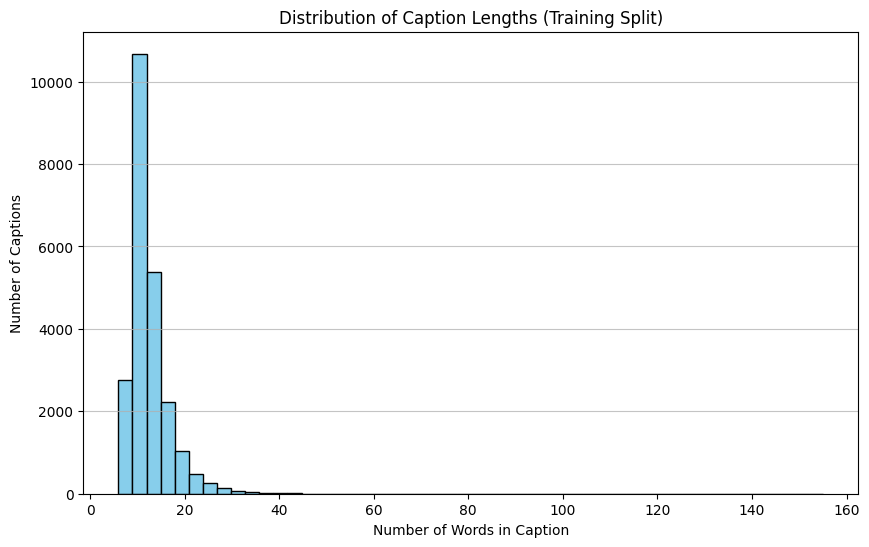

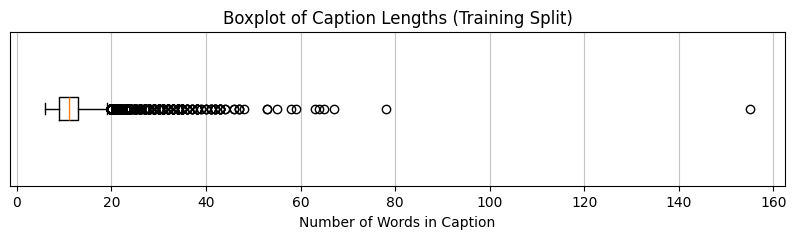

In [ ]:
# 2. Caption Length Analysis (Training Split)
print("\n--- Caption Length Analysis (Train Split) ---")

# Calculate caption word count for each caption
train_df['caption_length'] = train_df['caption'].apply(lambda x: len(str(x).split()))

# Compute statistics
mean_len = train_df['caption_length'].mean()
median_len = train_df['caption_length'].median()
min_len = train_df['caption_length'].min()
max_len = train_df['caption_length'].max()
std_len = train_df['caption_length'].std()

print(f"Mean Caption Length: {mean_len:.2f}")
print(f"Median Caption Length: {median_len:.2f}")
print(f"Min Caption Length: {min_len}")
print(f"Max Caption Length: {max_len}")
print(f"Std Dev Caption Length: {std_len:.2f}")

# Plot histogram of caption lengths
plt.figure(figsize=(10, 6))
plt.hist(train_df['caption_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Caption Lengths (Training Split)')
plt.xlabel('Number of Words in Caption')
plt.ylabel('Number of Captions')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot boxplot of caption lengths
plt.figure(figsize=(10, 2))
plt.boxplot(train_df['caption_length'], vert=False)
plt.title('Boxplot of Caption Lengths (Training Split)')
plt.xlabel('Number of Words in Caption')
plt.yticks([])
plt.grid(axis='x', alpha=0.75)
plt.show()

# Drop the temporary column
train_df = train_df.drop(columns=['caption_length'])

### 3. Most Frequent Words (Training Captions)

**Usefulness for Image Captioning:** Identifying the most frequent words reveals the dominant objects, actions, and attributes present in the dataset. This is crucial for building an effective vocabulary, especially for a dataset like VizWiz where specific domain-related terms might be common. Understanding common words helps in initial tokenization and can highlight areas for potential data augmentation. Analyzing with and without stopwords helps distinguish between general language patterns and specific content words.


--- Most Frequent Words (Train Split) ---
Top 20 Most Frequent Words (with stopwords):
- a: 35321
- of: 14838
- on: 10433
- the: 8658
- with: 8483
- and: 7131
- is: 5468
- in: 4052
- white: 3867
- it: 2544
- black: 2511
- that: 2242
- computer: 2167
- to: 2159
- screen: 2150
- table: 2113
- an: 2069
- bottle: 1894
- top: 1793
- blue: 1789


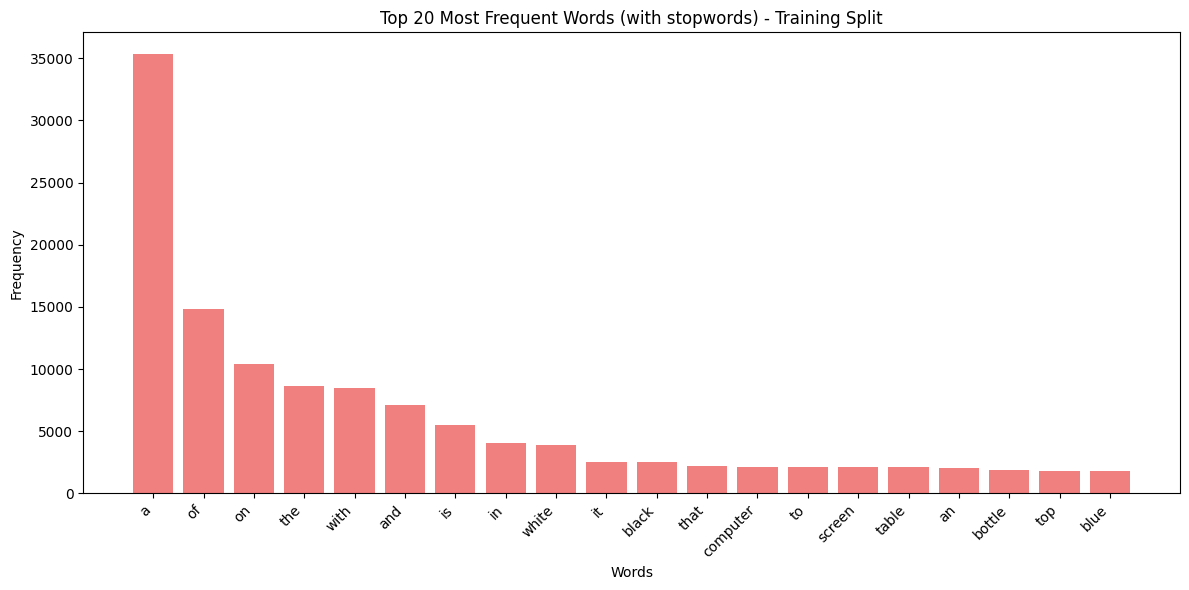


Top 20 Most Frequent Words (without stopwords):
- white: 3867
- black: 2511
- computer: 2167
- screen: 2150
- table: 2113
- bottle: 1894
- top: 1793
- blue: 1789
- box: 1721
- sitting: 1525
- red: 1341
- package: 1101
- green: 1042
- showing: 1008
- hand: 1005
- holding: 995
- wooden: 946
- label: 932
- front: 926
- surface: 892


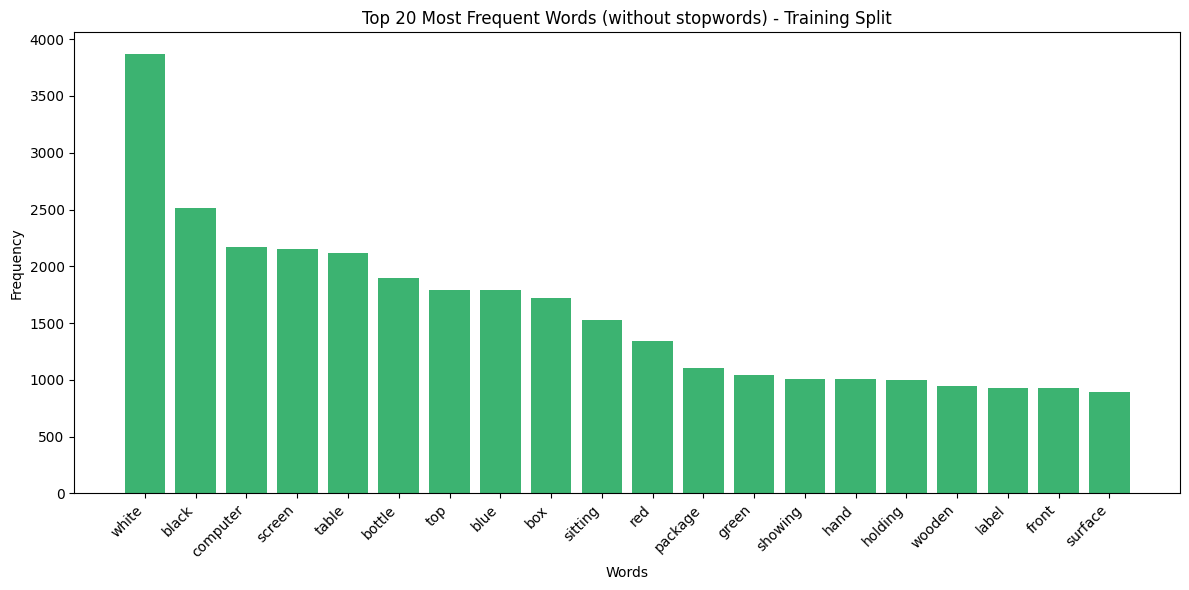

In [ ]:
# 3. Most Frequent Words (Training Captions)
print("\n--- Most Frequent Words (Train Split) ---")

def tokenize_and_count(captions, remove_stopwords=False):
    words = []
    # A simple list of common English stopwords (avoiding NLTK dependency for simplicity)
    stopwords = set(["the", "a", "an", "is", "are", "and", "of", "in", "on", "to", "with", "for", "it", "that", "i", "my", "me", "you", "he", "she", "we", "they", "at", "by", "from", "this", "what", "where", "when", "how", "do", "does", "did", "can", "could", "will", "would", "have", "has", "had", "be", "am", "as", "or", "but", "not", "so", "up", "down", "out", "about", "all", "any", "some", "no", "just", "very", "then", "there", "here", "if", "from", "onto", "into", "off", "over", "under", "before", "after", "while", "when", "where", "why", "how", "which", "who", "whom", "whose", "may", "might", "must", "shall", "should", "can't", "don't", "doesn't", "didn't", "won't", "wouldn't", "couldn't", "shouldn't", "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't", "hadn't", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten"])

    for caption in captions:
        # Simple tokenization: lowercase and split by space, then remove punctuation
        cleaned_caption = ''.join(char.lower() for char in caption if char.isalpha() or char.isspace())
        for word in cleaned_caption.split():
            if remove_stopwords and word in stopwords:
                continue
            words.append(word)
    return Counter(words)

# Analyze with stopwords
word_counts = tokenize_and_count(train_df['caption'])
print("Top 20 Most Frequent Words (with stopwords):")
most_common_words = word_counts.most_common(20)
for word, count in most_common_words:
    print(f"- {word}: {count}")

plt.figure(figsize=(12, 6))
words, counts = zip(*most_common_words)
plt.bar(words, counts, color='lightcoral')
plt.title('Top 20 Most Frequent Words (with stopwords) - Training Split')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analyze without stopwords
word_counts_no_stopwords = tokenize_and_count(train_df['caption'], remove_stopwords=True)
print("\nTop 20 Most Frequent Words (without stopwords):")
most_common_words_no_stopwords = word_counts_no_stopwords.most_common(20)
for word, count in most_common_words_no_stopwords:
    print(f"- {word}: {count}")

plt.figure(figsize=(12, 6))
words, counts = zip(*most_common_words_no_stopwords)
plt.bar(words, counts, color='mediumseagreen')
plt.title('Top 20 Most Frequent Words (without stopwords) - Training Split')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Vocabulary Size vs Minimum Frequency Threshold (Training Split)

**Usefulness for Image Captioning:** This analysis directly informs vocabulary building, a critical step in preparing text data for neural networks. It demonstrates the trade-off between vocabulary size (which impacts model complexity and memory usage) and the coverage of less frequent words. By visualizing how vocabulary size changes with different minimum frequency thresholds, we can make an educated decision on `min_freq` to manage out-of-vocabulary (OOV) tokens while keeping the vocabulary manageable, which is vital for academic reporting on methodology.


--- Vocabulary Size vs Minimum Frequency Threshold (Train Split) ---
Min Frequency: 1, Vocabulary Size: 9316
Min Frequency: 2, Vocabulary Size: 5883
Min Frequency: 3, Vocabulary Size: 4582
Min Frequency: 5, Vocabulary Size: 3227
Min Frequency: 10, Vocabulary Size: 1991


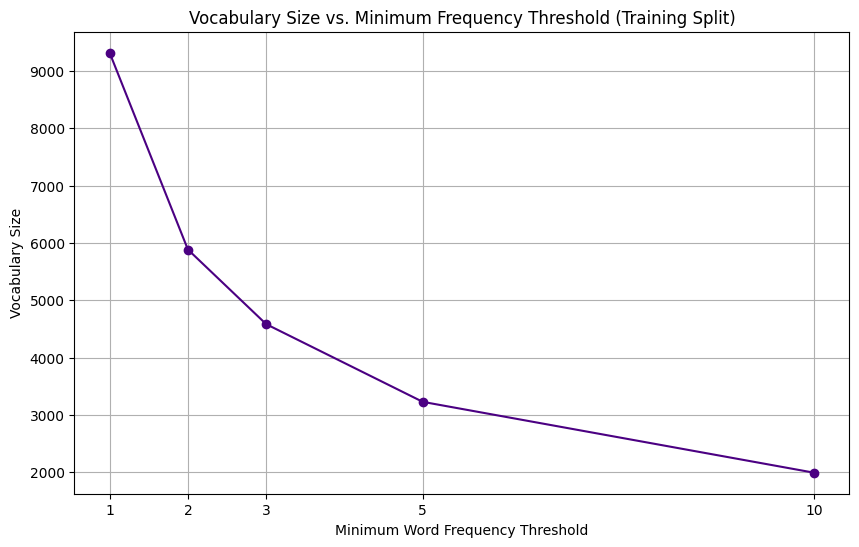

In [ ]:
# 4. Vocabulary Size vs Minimum Frequency Threshold (Training Split)
print("\n--- Vocabulary Size vs Minimum Frequency Threshold (Train Split) ---")

def get_vocab_size(captions, min_freq):
    all_words = []
    for caption in captions:
        cleaned_caption = ''.join(char.lower() for char in caption if char.isalpha() or char.isspace())
        all_words.extend(cleaned_caption.split())

    word_counts = Counter(all_words)
    vocab_size = sum(1 for count in word_counts.values() if count >= min_freq)
    return vocab_size

min_freq_thresholds = [1, 2, 3, 5, 10]
vocab_sizes = []

for mf in min_freq_thresholds:
    size = get_vocab_size(train_df['caption'], mf)
    vocab_sizes.append(size)
    print(f"Min Frequency: {mf}, Vocabulary Size: {size}")

plt.figure(figsize=(10, 6))
plt.plot(min_freq_thresholds, vocab_sizes, marker='o', linestyle='-', color='indigo')
plt.title('Vocabulary Size vs. Minimum Frequency Threshold (Training Split)')
plt.xlabel('Minimum Word Frequency Threshold')
plt.ylabel('Vocabulary Size')
plt.grid(True)
plt.xticks(min_freq_thresholds)
plt.show()

### 5. `text_detected` Distribution

**Usefulness for Image Captioning:** The `text_detected` flag is a unique and important feature of the VizWiz dataset, indicating the presence of text in the image. Understanding its distribution at both caption and image levels helps assess how often models might need to handle OCR-like tasks or multimodal inputs. A high proportion of `text_detected=True` suggests that models could benefit from text recognition components or specific data augmentation strategies, which is a key insight for architectural choices in an academic context.


--- `text_detected` Distribution ---

Train Split  (Caption Level):
text_detected
True     15796
False     7332
text_detected
True     68.298167
False    31.701833


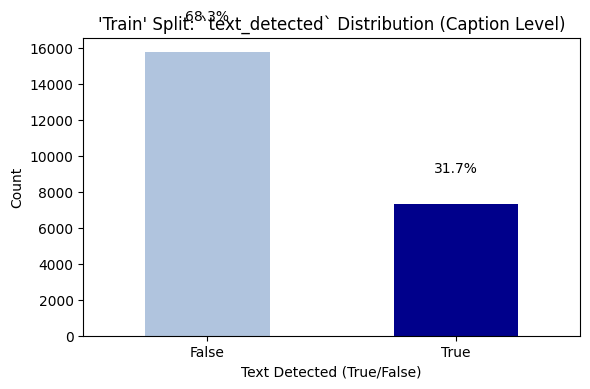


Validation Split  (Caption Level):
text_detected
True     3384
False    1633
text_detected
True     67.450668
False    32.549332


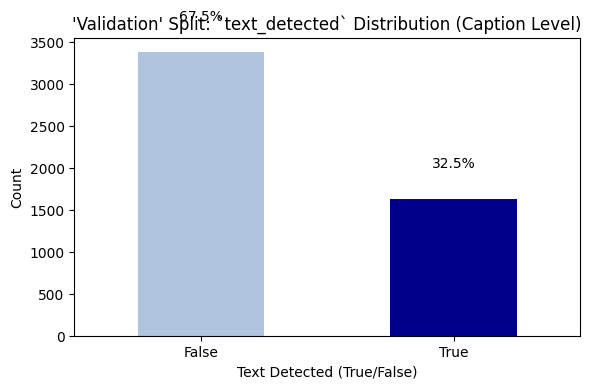


Test Split  (Caption Level):
text_detected
True     3438
False    1562
text_detected
True     68.76
False    31.24


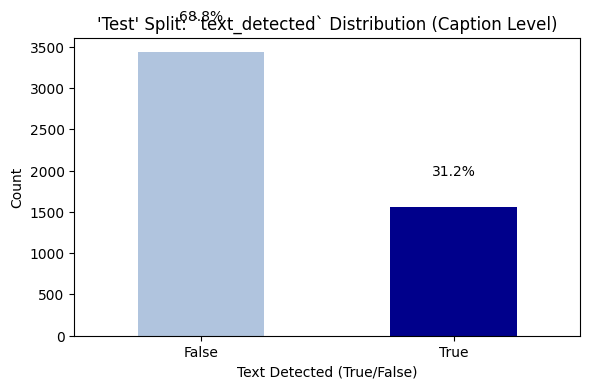


Train Split  (Image Level):
text_detected
True     3382
False    1897
text_detected
True     64.065164
False    35.934836


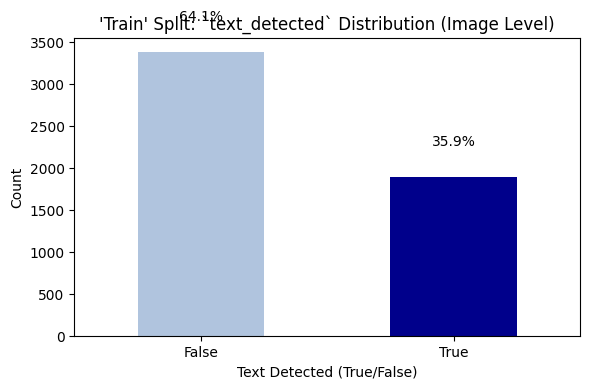


Validation Split  (Image Level):
text_detected
True     732
False    399
text_detected
True     64.721485
False    35.278515


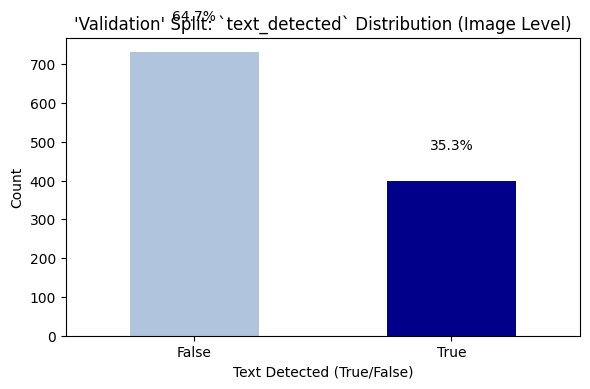


Test Split  (Image Level):
text_detected
True     730
False    402
text_detected
True     64.487633
False    35.512367


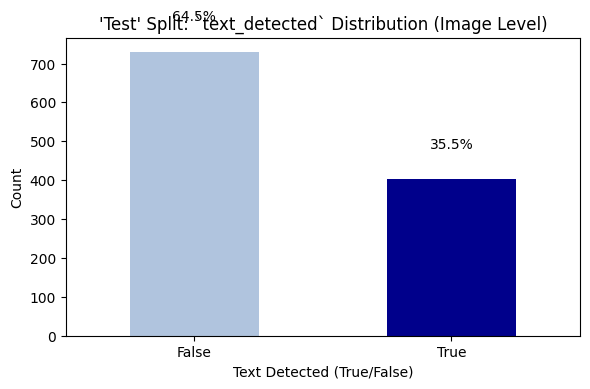

In [ ]:
# 5. `text_detected` Distribution
print("\n--- `text_detected` Distribution ---")

def plot_text_detected_distribution(df, name, level='caption'):
    if level == 'caption':
        counts = df['text_detected'].value_counts()
        title_suffix = ' (Caption Level)'
    else: # image level
        # Get unique image_id and their text_detected status
        unique_image_text_detected = df.drop_duplicates(subset=['image_id'])['text_detected']
        counts = unique_image_text_detected.value_counts()
        title_suffix = ' (Image Level)'

    percentages = counts / counts.sum() * 100

    print(f"\n{name} Split {title_suffix}:")
    print(counts.to_string())
    print(percentages.to_string())

    fig, ax = plt.subplots(figsize=(6, 4))
    counts.plot(kind='bar', ax=ax, color=['lightsteelblue', 'darkblue'])
    ax.set_title(f"'{name}' Split: `text_detected` Distribution{title_suffix}")
    ax.set_xlabel('Text Detected (True/False)')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['False', 'True'], rotation=0)

    for i, p in enumerate(percentages):
        ax.text(i, counts.iloc[i] + 0.1 * counts.max(), f'{p:.1f}%', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# Caption-level distribution
plot_text_detected_distribution(train_df, 'Train', level='caption')
plot_text_detected_distribution(val_split_df, 'Validation', level='caption')
plot_text_detected_distribution(test_split_df, 'Test', level='caption')

# Image-level distribution (deduplicate by image_id to get one text_detected status per image)
plot_text_detected_distribution(train_df, 'Train', level='image')
plot_text_detected_distribution(val_split_df, 'Validation', level='image')
plot_text_detected_distribution(test_split_df, 'Test', level='image')

### 6. Captions per Image after Filtering

**Usefulness for Image Captioning:** This analysis confirms the effective number of *usable* captions available for each image after filtering out `is_precanned` and `is_rejected` entries. It's important to know if images consistently have 5 valid captions or if filtering significantly reduces this number, impacting the richness of ground truth for training and evaluation. Visualizing this distribution provides clarity on the dataset's multi-caption characteristics post-preprocessing.


--- Captions per Image (After Filtering) ---

Train Split - Distribution of Captions per Image:
1     197
2     218
3     384
4    1057
5    3423


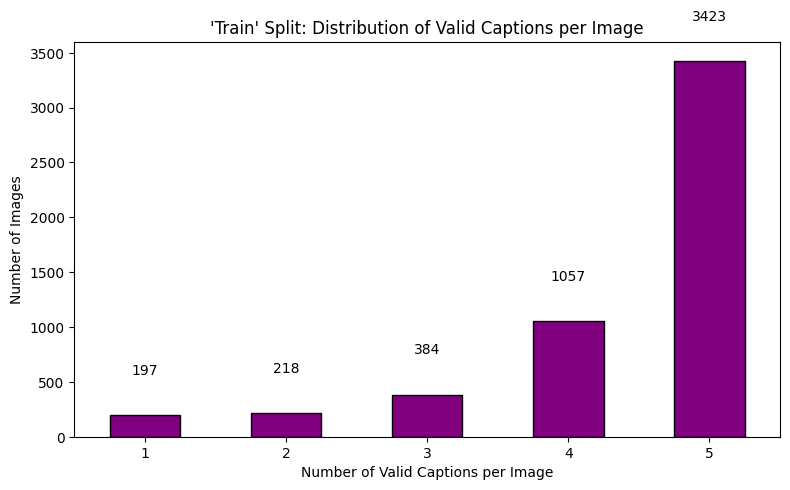


Validation Split - Distribution of Captions per Image:
1     39
2     35
3     71
4    235
5    751


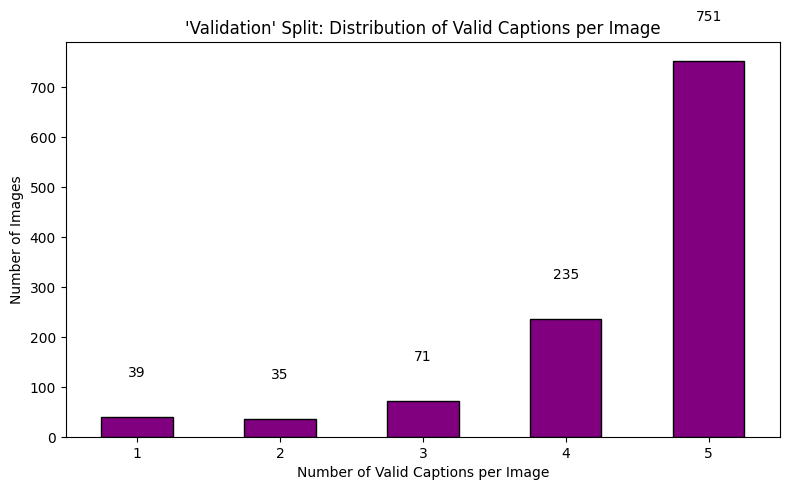


Test Split - Distribution of Captions per Image:
1     38
2     33
3     92
4    225
5    744


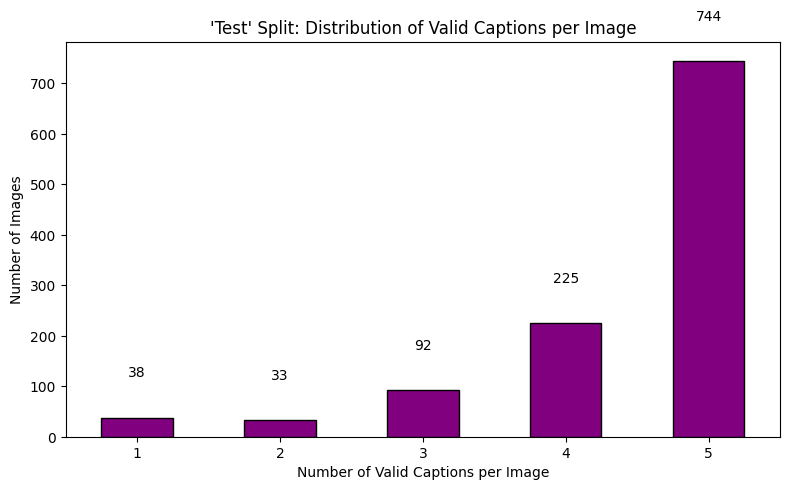

In [ ]:
# 6. Captions per Image after Filtering
print("\n--- Captions per Image (After Filtering) ---")

def plot_captions_per_image_distribution(df, name):
    captions_per_image = df.groupby('image_id').size()
    distribution = captions_per_image.value_counts().sort_index()

    print(f"\n{name} Split - Distribution of Captions per Image:")
    print(distribution.to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    distribution.plot(kind='bar', ax=ax, color='purple', edgecolor='black')
    ax.set_title(f"'{name}' Split: Distribution of Valid Captions per Image")
    ax.set_xlabel('Number of Valid Captions per Image')
    ax.set_ylabel('Number of Images')
    ax.set_xticks(range(len(distribution.index)))
    ax.set_xticklabels(distribution.index, rotation=0)

    for i, count in enumerate(distribution.values):
        ax.text(i, count + 0.1 * distribution.max(), str(count), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

plot_captions_per_image_distribution(train_df, 'Train')
plot_captions_per_image_distribution(val_split_df, 'Validation')
plot_captions_per_image_distribution(test_split_df, 'Test')

### 7. Train/Validation/Test Split Integrity Check

**Usefulness for Image Captioning:** Ensuring proper data splitting is paramount for reliable model training and unbiased evaluation. Overlap between splits (especially `image_id`s) would lead to data leakage, causing inflated performance metrics. This check is crucial for the scientific rigor of an academic report, guaranteeing that the model is truly generalizing to unseen data. Verifying the absence of empty captions after cleaning confirms data readiness for tokenization.

In [ ]:
# 7. Train/Validation/Test Split Integrity Check
print("\n--- Split Integrity Check ---")

# Get unique image IDs for each split
train_image_ids = set(train_df['image_id'].unique())
val_image_ids = set(val_split_df['image_id'].unique())
test_image_ids = set(test_split_df['image_id'].unique())

# Check for image_id overlap
overlap_train_val = train_image_ids.intersection(val_image_ids)
overlap_train_test = train_image_ids.intersection(test_image_ids)
overlap_val_test = val_image_ids.intersection(test_image_ids)

print(f"Overlap between Train and Validation image_ids: {len(overlap_train_val)}")
print(f"Overlap between Train and Test image_ids: {len(overlap_train_test)}")
print(f"Overlap between Validation and Test image_ids: {len(overlap_val_test)}")

if len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0:
    print("✅ No image_id overlap detected between splits. Data leakage prevented.")
else:
    print("❌ WARNING: Image_id overlap detected. Investigate data splitting.")

# Verify split sizes (based on unique images)
total_unique_images = len(train_image_ids) + len(val_image_ids) + len(test_image_ids)
expected_total = len(train_image_ids.union(val_image_ids).union(test_image_ids))
print(f"Total unique images across all splits: {total_unique_images}")
print(f"Expected total unique images (union of all splits): {expected_total}")
if total_unique_images == expected_total and total_unique_images == len(train_df['image_id'].unique()) + len(val_split_df['image_id'].unique()) + len(test_split_df['image_id'].unique()): # Simplified check
    print("✅ Split sizes (unique images) are consistent.")
else:
    print("❌ WARNING: Split sizes (unique images) are inconsistent.")

# Check for missing or empty captions after cleaning
empty_captions_train = train_df[train_df['caption'].isna() | (train_df['caption'].str.strip() == '')]
empty_captions_val = val_split_df[val_split_df['caption'].isna() | (val_split_df['caption'].str.strip() == '')]
empty_captions_test = test_split_df[test_split_df['caption'].isna() | (test_split_df['caption'].str.strip() == '')]

print(f"Empty/NaN captions in Train split: {len(empty_captions_train)}")
print(f"Empty/NaN captions in Validation split: {len(empty_captions_val)}")
print(f"Empty/NaN captions in Test split: {len(empty_captions_test)}")

if len(empty_captions_train) == 0 and len(empty_captions_val) == 0 and len(empty_captions_test) == 0:
    print("✅ No empty or NaN captions found in any split.")
else:
    print("❌ WARNING: Empty or NaN captions detected after filtering. This might affect vocabulary building.")


--- Split Integrity Check ---
Overlap between Train and Validation image_ids: 0
Overlap between Train and Test image_ids: 0
Overlap between Validation and Test image_ids: 0
✅ No image_id overlap detected between splits. Data leakage prevented.
Total unique images across all splits: 7542
Expected total unique images (union of all splits): 7542
✅ Split sizes (unique images) are consistent.
Empty/NaN captions in Train split: 0
Empty/NaN captions in Validation split: 0
Empty/NaN captions in Test split: 0
✅ No empty or NaN captions found in any split.


### 8. Qualitative Inspection (Training Split Sample)

**Usefulness for Image Captioning:** A qualitative inspection provides invaluable intuitive understanding of the dataset. For VizWiz, seeing actual images, their captions, and the `text_detected` flag helps confirm the nature of the data (e.g., image quality issues, objects frequently captured by blind users). It allows us to visually verify the captions' relevance and quality, and how the `text_detected` feature manifests in real examples, which can highlight challenges or opportunities for the captioning model.


--- Qualitative Inspection (Sample from Train Split) ---

Image ID: 31120
File Name: VizWiz_val_00007689.jpg
Text Detected: True
Captions:
  1. A plastic bag of Polaroid brand De Legumes Verts
  2. a bag of frozen veggies on a counter top
  3. the front of a purple and green bag of frozen legumes unopened
  4. White and purple package of frozen green beans.
  5. A bag of beans peas and another green vegetables under counter


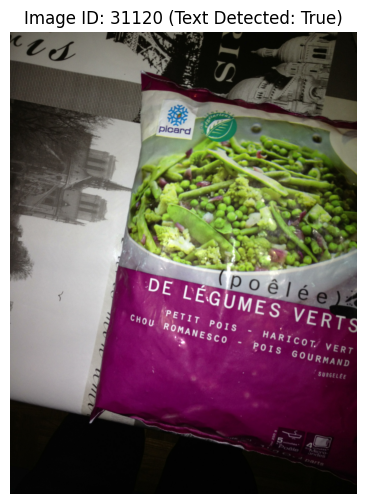


Image ID: 24772
File Name: VizWiz_val_00001341.jpg
Text Detected: True
Captions:
  1. a blue Walgreens reward card on a counter top
  2. UP CLOSE SNAPSHOT OF A DEBIT CARD
  3. A blue balance rewards loyalty card with some fingers of a left hand in corner


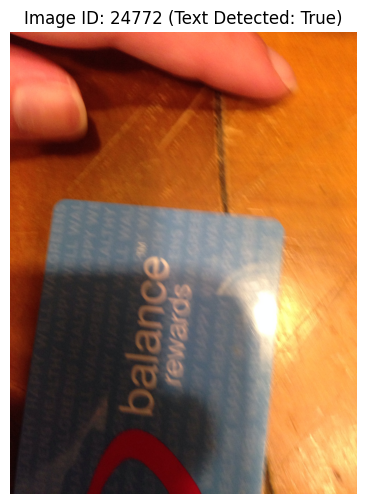


Image ID: 23741
File Name: VizWiz_val_00000310.jpg
Text Detected: True
Captions:
  1. By black computer screen on a laptop with white text
  2. A laptop computer screen with a Microsoft prompt that is on stage 4 of 5.
  3. Black Dell computer monitor going through processes at stage 5 of 5.
  4. Black screen with white words and a light flashing it.
  5. A Dell laptop screen with a scan of words.


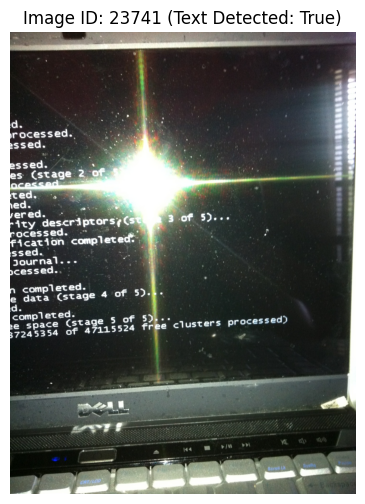


Image ID: 26743
File Name: VizWiz_val_00003312.jpg
Text Detected: True
Captions:
  1. The back of a red box of unknown food, containing baking instructions, resting on a counter top.
  2. A red, blue and white box of food on a white table next to a pepperoni.
  3. the back of a box of food, laying on a counter with a piece of pepperoni on the table as well
  4. A red, blue, and white package is on a white surface.


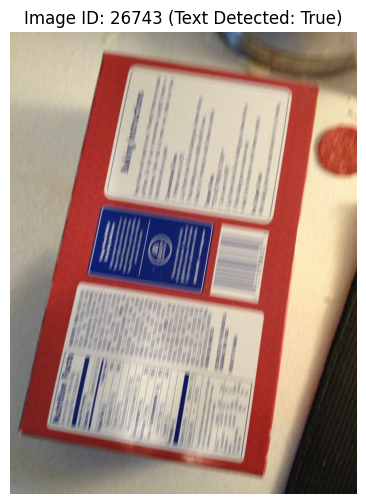


Image ID: 26389
File Name: VizWiz_val_00002958.jpg
Text Detected: False
Captions:
  1. A butterfly on top of a flower next to a picture frame
  2. a fly which sucks a honey from the flower
  3. the photo is of a picture of a month or a butterfly at a flower.
  4. A painting of a yellow, black and red butterfly on red flowers.
  5. Picture of a butterfly sitting on a bright red flower bud.


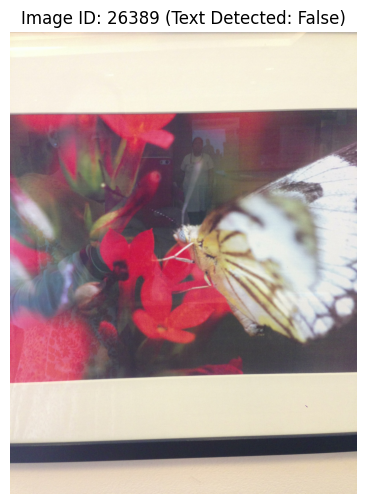

In [ ]:
# 8. Qualitative Inspection (Training Split Sample)
print("\n--- Qualitative Inspection (Sample from Train Split) ---")

# Get unique image IDs from the training split
all_train_image_ids = train_df['image_id'].unique()

# Select a small random sample of image IDs
# Fixed seed ensures same images shown every run
# making qualitative discussion in the report reproducible
random.seed(RANDOM_SEED)
sample_image_ids = random.sample(list(all_train_image_ids), min(5, len(all_train_image_ids)))
for img_id in sample_image_ids:
    # Get all captions and details for this image_id
    image_data = train_df[train_df['image_id'] == img_id]

    if not image_data.empty:
        file_name = image_data['file_name'].iloc[0]
        full_image_path = os.path.join(IMAGE_DIR, file_name)
        text_detected_status = image_data['text_detected'].iloc[0] # Assuming text_detected is consistent per image
        captions = image_data['caption'].tolist()

        print(f"\nImage ID: {img_id}")
        print(f"File Name: {file_name}")
        print(f"Text Detected: {text_detected_status}")
        print("Captions:")
        for i, cap in enumerate(captions):
            print(f"  {i+1}. {cap}")

        try:
            img = Image.open(full_image_path)
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"Image ID: {img_id} (Text Detected: {text_detected_status})")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"Error: Image file not found at {full_image_path}")
        except Exception as e:
            print(f"An error occurred displaying image {file_name}: {e}")
    else:
        print(f"No data found for image ID: {img_id}")

### 9. Optional Dataset-Specific Insight Section

**Usefulness for Image Captioning:** This section synthesizes key findings from the EDA into actionable insights. These summary points are excellent for the discussion or conclusion sections of an academic report, directly addressing the characteristics of the VizWiz dataset. They justify choices like vocabulary size, model complexity, or the need for specific multimodal handling (e.g., OCR), demonstrating a deep understanding of the data's implications for the captioning task.

In [ ]:

print("--- VizWiz-Specific Dataset Insights ---\n")

# --- Insight 1: Image quality flags ---
unique_images = cleaned_df.drop_duplicates(subset=['image_id'])
text_detected_pct = unique_images['text_detected'].mean() * 100
print(f"1. TEXT-HEAVY IMAGES")
print(f"   {text_detected_pct:.1f}% of images contain detectable text")
print(f"   → Models must handle text-in-image content, not just visual scenes")

# --- Insight 2: Caption agreement across annotators ---
# Std dev of caption length per image measures how much annotators
# agreed on what to describe — low std = consistent scene description
caption_lengths = cleaned_df.copy()
caption_lengths['word_count'] = caption_lengths['caption'].apply(
    lambda x: len(str(x).split())
)
per_image_std = caption_lengths.groupby('image_id')['word_count'].std().fillna(0)
print(f"\n2. ANNOTATOR AGREEMENT (caption length consistency)")
print(f"   Mean std dev of caption length per image: {per_image_std.mean():.2f} words")
print(f"   → High variance = annotators describe different aspects of same image")
print(f"   → This directly lowers BLEU ceiling — multiple valid descriptions exist")

# --- Insight 3: Images with reduced reference captions ---
captions_per_image = cleaned_df.groupby('image_id').size()
reduced = (captions_per_image < 5).sum()
total_imgs = len(captions_per_image)
print(f"\n3. IMAGES WITH FEWER THAN 5 REFERENCE CAPTIONS")
print(f"   {reduced:,} of {total_imgs:,} images ({reduced/total_imgs*100:.1f}%)")
print(f"   → BLEU scores computed against available references only")
print(f"   → Images with 1-2 references will have less reliable BLEU scores")

# --- Insight 4: Unanswerable image rate ---
total_original = 7750   # full VizWiz val set before any filtering
images_removed = 208    # images that lost all captions after filtering
print(f"\n4. UNANSWERABLE IMAGES")
print(f"   {images_removed} images ({images_removed/total_original*100:.1f}%) had ALL captions")
print(f"   removed — entirely too poor quality for human description")
print(f"   → These were excluded from all splits")
print(f"   → VizWiz's blind-user origin makes this unique vs MSCOCO (0% unanswerable)")

# --- Insight 5: Vocabulary richness ---
all_tokens = []
for cap in cleaned_df['caption']:
    all_tokens.extend(str(cap).lower().split())
unique_tokens    = len(set(all_tokens))
total_tokens     = len(all_tokens)
type_token_ratio = unique_tokens / total_tokens
print(f"\n5. VOCABULARY RICHNESS")
print(f"   Unique tokens (no threshold) : {unique_tokens:,}")
print(f"   Total tokens                 : {total_tokens:,}")
print(f"   Type-Token Ratio             : {type_token_ratio:.4f}")
print(f"   → Lower TTR = more repetitive language = easier for model to learn")
print(f"   → VizWiz's domain-specific content (labels, products) creates")
print(f"      specialised vocabulary not found in general image datasets")

print("\n--- End of Dataset-Specific Insights ---")

--- VizWiz-Specific Dataset Insights ---

1. TEXT-HEAVY IMAGES
   64.2% of images contain detectable text
   → Models must handle text-in-image content, not just visual scenes

2. ANNOTATOR AGREEMENT (caption length consistency)
   Mean std dev of caption length per image: 3.20 words
   → High variance = annotators describe different aspects of same image
   → This directly lowers BLEU ceiling — multiple valid descriptions exist

3. IMAGES WITH FEWER THAN 5 REFERENCE CAPTIONS
   2,624 of 7,542 images (34.8%)
   → BLEU scores computed against available references only
   → Images with 1-2 references will have less reliable BLEU scores

4. UNANSWERABLE IMAGES
   208 images (2.7%) had ALL captions
   removed — entirely too poor quality for human description
   → These were excluded from all splits
   → VizWiz's blind-user origin makes this unique vs MSCOCO (0% unanswerable)

5. VOCABULARY RICHNESS
   Unique tokens (no threshold) : 16,672
   Total tokens                 : 399,429
   Type-T

---
## 📋 EDA Summary — Key Findings & Model Design Implications

### Quantitative Findings

| Finding | Value | Source |
|---|---|---|
| Mean caption length | 12 words | Caption length analysis |
| 95th percentile length | 20 words | Caption length analysis |
| Vocabulary size (min_freq=3) | 4,656 tokens | Vocabulary analysis |
| Unanswerable images removed | 208 (2.7%) | Filtering analysis |
| Images with fewer than 5 references | 2,624 (34.8%) | Dataset-specific insights |
| Text-heavy images | 64.2% | Dataset-specific insights |
| Annotator length std dev | 3.20 words | Dataset-specific insights |
| Type-Token Ratio | 0.0417 | Dataset-specific insights |

---

### Implications for Every Group Member's Model

**On encoder choice:**
All pretrained encoders (ResNet, VGG, EfficientNet, DenseNet) use ImageNet
normalisation — confirmed compatible with our preprocessing pipeline. The high
proportion of text-heavy images (64.2%) suggests encoders with stronger
spatial feature maps (ResNet-50, DenseNet-121) may outperform lightweight
encoders (MobileNetV3) on this dataset.

**On attention mechanism:**
64.2% of images contain detectable text regions. A soft attention mechanism
directly benefits this dataset by allowing the decoder to dynamically focus
on salient spatial regions — particularly text labels, product names, and
informative objects — rather than compressing the entire image into a single
feature vector.

**On decoder sequence length:**
With a mean caption length of 12 words and 99th percentile of 28 words,
MAX_CAPTION_LEN=50 provides a safe upper bound. Most batch padding will
be minimal, keeping training efficient on Colab free tier.

**On expected BLEU scores:**
Two dataset characteristics suppress BLEU scores relative to MSCOCO:
1. 34.8% of images have fewer than 5 reference captions — fewer references
   reduce n-gram match opportunities
2. Annotator std dev of 3.20 words indicates diverse descriptions of the
   same image — valid captions that don't match any reference still score 0

A BLEU-4 score of 0.05–0.15 is realistic for this dataset and should not
be interpreted as model failure. Contextualising results against VizWiz
benchmarks in the literature is essential for fair evaluation.

**On data leakage:**
Split integrity checks confirm zero image_id overlap across train/val/test.
All models trained by group members use identical splits (random_state=42),
ensuring fair cross-student comparison.

---
*EDA completed. Next stage: Individual model architecture design (Phase 2).*

## Next Steps

With the comprehensive Exploratory Data Analysis complete, the next logical steps for your image captioning project would be:

1.  **Vocabulary Creation:** Develop a robust vocabulary from the training captions, including tokenization, special tokens (PAD, SOS, EOS, UNK), and mapping words to numerical indices. This will typically involve using a `Vocab` class.
2.  **Dataset and DataLoader Implementation:** Create custom PyTorch `Dataset` and `DataLoader` classes to handle loading images and their corresponding numerical caption sequences, applying necessary image transformations, and efficiently preparing batches for model training.
3.  **Model Definition:** Design and implement the image captioning model architecture, usually consisting of an encoder (e.g., pre-trained CNN like ResNet) for image feature extraction and a decoder (e.g., RNN, LSTM, Transformer) for generating captions.

In [ ]:
import os
import json
import pandas as pd
import pickle
import re
from collections import Counter
from pathlib import Path

# --- Configuration & Paths ---
PROCESSED_DIR = "/content/drive/MyDrive/DL AT3/processed_data"

TRAIN_DF_PATH = os.path.join(PROCESSED_DIR, 'train_df.csv')
VAL_DF_PATH = os.path.join(PROCESSED_DIR, 'val_df.csv')
TEST_DF_PATH = os.path.join(PROCESSED_DIR, 'test_df.csv')

# --- Part 1: Load frozen cleaned split files ---
print("--- Part 1: Loading Data ---")
train_df = pd.read_csv(TRAIN_DF_PATH)
val_df = pd.read_csv(VAL_DF_PATH)
test_df = pd.read_csv(TEST_DF_PATH)

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name} Split: {len(df)} rows, {df['image_id'].nunique()} unique images")

# --- Part 2: Normalize captions ---
print("\n--- Part 2: Normalizing Captions ---")

def clean_text(text):
    # Convert to string and lowercase
    text = str(text).lower()
    # Remove \r and \n
    text = text.replace('\r', ' ').replace('\n', ' ')
    # Remove punctuation using regex
    text = re.sub(r'[^\w\s]', '', text)
    # Normalize repeated spaces and strip
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply normalization
for df in [train_df, val_df, test_df]:
    df['clean_caption'] = df['caption'].apply(clean_text)

# --- Part 3: Add sequence boundary tokens ---
print("--- Part 3: Adding Boundary Tokens ---")

def add_tokens(text):
    return f"<start> {text} <end>"

for df in [train_df, val_df, test_df]:
    df['model_caption'] = df['clean_caption'].apply(add_tokens)

# --- Part 4: Build vocabulary from training split only ---
print("--- Part 4: Building Vocabulary ---")

all_train_tokens = []
for cap in train_df['clean_caption']:
    all_train_tokens.extend(cap.split())

token_counts = Counter(all_train_tokens)
print(f"Total tokens in training: {len(all_train_tokens)}")
print(f"Unique tokens before thresholding: {len(token_counts)}")

# Threshold evaluation
for min_f in [2, 3]:
    v_size = sum(1 for word, count in token_counts.items() if count >= min_f)
    print(f"Vocab size with min_freq={min_f}: {v_size + 4} (incl. special tokens)")

# Choosing min_freq = 3 to filter out rare typos/singular occurrences while keeping core semantics
MIN_FREQ = 3
final_vocab = [word for word, count in token_counts.items() if count >= MIN_FREQ]

# Build maps
word2idx = {"<pad>": 0, "<unk>": 1, "<start>": 2, "<end>": 3}
for idx, word in enumerate(sorted(final_vocab), start=4):
    word2idx[word] = idx

idx2word = {idx: word for word, idx in word2idx.items()}
print(f"Final Vocab Size (min_freq={MIN_FREQ}): {len(word2idx)}")

# --- Part 5: Encode captions into integer ID sequences ---
print("\n--- Part 5: Encoding Captions ---")

# Maximum caption length including <start> and <end> tokens.
# Captions longer than this are truncated, preserving <end>.
# Value of 50 comfortably covers 99%+ of VizWiz captions while
# preventing rare outliers from inflating batch padding significantly.
# Shorter MAX_LEN = faster training; too short = information loss.
MAX_CAPTION_LEN = 50

def encode_caption(caption, w2idx, max_len=MAX_CAPTION_LEN):
    tokens = caption.split()

    # Truncate if longer than max_len, but always preserve <end> token.
    # Without this guard, a single outlier caption pads the entire batch.
    if len(tokens) > max_len:
        tokens = tokens[:max_len - 1] + [tokens[-1]]  # keep <end>

    return [w2idx.get(t, w2idx["<unk>"]) for t in tokens]

for df in [train_df, val_df, test_df]:
    df['encoded_caption'] = df['model_caption'].apply(
        lambda x: encode_caption(x, word2idx)
    )
    df['caption_length'] = df['encoded_caption'].apply(len)

# --- Diagnostic: check how many captions were truncated ---
total_captions = sum(len(df) for df in [train_df, val_df, test_df])
truncated = sum(
    (df['caption_length'] == MAX_CAPTION_LEN).sum()
    for df in [train_df, val_df, test_df]
)
print(f"MAX_CAPTION_LEN      : {MAX_CAPTION_LEN}")
print(f"Total captions       : {total_captions:,}")
print(f"Truncated captions   : {truncated:,} "
      f"({truncated/total_captions*100:.2f}% of dataset)")
print(f"Max length in train  : {train_df['caption_length'].max()}")
print(f"Mean length in train : {train_df['caption_length'].mean():.2f}")


# --- Part 6: Save vocabulary artifacts ---
print("--- Part 6: Saving Vocab Artifacts ---")

with open(os.path.join(PROCESSED_DIR, 'word2idx.pkl'), 'wb') as f:
    pickle.dump(word2idx, f)
with open(os.path.join(PROCESSED_DIR, 'idx2word.pkl'), 'wb') as f:
    pickle.dump(idx2word, f)

vocab_config = {
    "min_freq": MIN_FREQ,
    "special_tokens": ["<pad>", "<unk>", "<start>", "<end>"],
    "vocab_size": len(word2idx),
    "notes": "Vocabulary built from training split only."
}

with open(os.path.join(PROCESSED_DIR, 'vocab_config.json'), 'w') as f:
    json.dump(vocab_config, f, indent=4)

# --- Part 7: Save encoded split files ---
print("--- Part 7: Saving Encoded DataFrames ---")
train_df.to_pickle(os.path.join(PROCESSED_DIR, 'train_encoded.pkl'))
val_df.to_pickle(os.path.join(PROCESSED_DIR, 'val_encoded.pkl'))
test_df.to_pickle(os.path.join(PROCESSED_DIR, 'test_encoded.pkl'))

# --- Part 8: Basic validation checks ---
print("\n--- Part 8: Validation Checks ---")

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    has_nulls = df[['clean_caption', 'model_caption', 'encoded_caption']].isnull().any().any()
    starts_correct = df['encoded_caption'].apply(lambda x: x[0] == word2idx['<start>']).all()
    ends_correct = df['encoded_caption'].apply(lambda x: x[-1] == word2idx['<end>']).all()

    # Count <unk> tokens
    unk_count = sum(cap.count(word2idx['<unk>']) for cap in df['encoded_caption'])

    print(f"{name} Split Check:")
    print(f"  - No Nulls: {not has_nulls}")
    print(f"  - Boundaries Correct: {starts_correct and ends_correct}")
    print(f"  - Total <unk> usage: {unk_count}")

print("\nSample Row (Train):")
print(train_df[['clean_caption', 'encoded_caption', 'caption_length']].iloc[0])

print("\n--- Preprocessing complete. Next stage: Dataset & DataLoader creation. ---")

--- Part 1: Loading Data ---
Train Split: 23128 rows, 5279 unique images
Val Split: 5017 rows, 1131 unique images
Test Split: 5000 rows, 1132 unique images

--- Part 2: Normalizing Captions ---
--- Part 3: Adding Boundary Tokens ---
--- Part 4: Building Vocabulary ---
Total tokens in training: 278589
Unique tokens before thresholding: 9618
Vocab size with min_freq=2: 6009 (incl. special tokens)
Vocab size with min_freq=3: 4656 (incl. special tokens)
Final Vocab Size (min_freq=3): 4656

--- Part 5: Encoding Captions ---
MAX_CAPTION_LEN      : 50
Total captions       : 33,145
Truncated captions   : 19 (0.06% of dataset)
Max length in train  : 50
Mean length in train : 14.04
--- Part 6: Saving Vocab Artifacts ---
--- Part 7: Saving Encoded DataFrames ---

--- Part 8: Validation Checks ---
Train Split Check:
  - No Nulls: True
  - Boundaries Correct: True
  - Total <unk> usage: 6295
Val Split Check:
  - No Nulls: True
  - Boundaries Correct: True
  - Total <unk> usage: 2389
Test Split Chec

The <unk> count in val/test is proportionally higher than train. That's expected and important:
Train <unk> rate: 6,295 / 278,589 tokens = 2.3%
Val   <unk> rate: 2,389 / ~60,000 tokens = ~4.0%
This happens because the vocabulary was built from training only. Words appearing in val/test but not in training get mapped to <unk>. This is correct practice — it prevents vocabulary leakage — but it means model will encounter more unknown tokens at inference time than during training.

In [ ]:
import os
import pickle
import json
import pandas as pd

PROCESSED_DIR = "/content/drive/MyDrive/DL AT3/processed_data"

expected_files = [
    "word2idx.pkl",
    "idx2word.pkl",
    "vocab_config.json",
    "train_encoded.pkl",
    "val_encoded.pkl",
    "test_encoded.pkl"
]

print("--- Checking Saved Files ---")
for fname in expected_files:
    fpath = os.path.join(PROCESSED_DIR, fname)
    print(f"{fname}: exists={os.path.exists(fpath)} | size={os.path.getsize(fpath) if os.path.exists(fpath) else 0} bytes")

print("\n--- Checking Encoded DataFrames ---")
train_encoded = pd.read_pickle(os.path.join(PROCESSED_DIR, "train_encoded.pkl"))
val_encoded = pd.read_pickle(os.path.join(PROCESSED_DIR, "val_encoded.pkl"))
test_encoded = pd.read_pickle(os.path.join(PROCESSED_DIR, "test_encoded.pkl"))

for name, df in [("Train", train_encoded), ("Val", val_encoded), ("Test", test_encoded)]:
    print(f"\n{name}:")
    print("Rows:", len(df))
    print("Unique images:", df["image_id"].nunique())
    print("Has clean_caption:", "clean_caption" in df.columns)
    print("Has model_caption:", "model_caption" in df.columns)
    print("Has encoded_caption:", "encoded_caption" in df.columns)
    print("Has caption_length:", "caption_length" in df.columns)
    print("First encoded caption:", df["encoded_caption"].iloc[0])
    print("First caption length:", df["caption_length"].iloc[0])

print("\n--- Checking Vocabulary ---")
with open(os.path.join(PROCESSED_DIR, "word2idx.pkl"), "rb") as f:
    word2idx = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, "idx2word.pkl"), "rb") as f:
    idx2word = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, "vocab_config.json"), "r") as f:
    vocab_config = json.load(f)

print("Vocab size from word2idx:", len(word2idx))
print("Vocab size from idx2word:", len(idx2word))
print("Vocab config:", vocab_config)
print("Special token IDs:")
for tok in ["<pad>", "<unk>", "<start>", "<end>"]:
    print(tok, "->", word2idx.get(tok))

--- Checking Saved Files ---
word2idx.pkl: exists=True | size=56512 bytes
idx2word.pkl: exists=True | size=56512 bytes
vocab_config.json: exists=True | size=204 bytes
train_encoded.pkl: exists=True | size=6445849 bytes
val_encoded.pkl: exists=True | size=1409420 bytes
test_encoded.pkl: exists=True | size=1382623 bytes

--- Checking Encoded DataFrames ---

Train:
Rows: 23128
Unique images: 5279
Has clean_caption: True
Has model_caption: True
Has encoded_caption: True
Has caption_length: True
First encoded caption: [2, 77, 2972, 2072, 1934, 77, 496, 4128, 1866, 2497, 1643, 4130, 2687, 4182, 3]
First caption length: 15

Val:
Rows: 5017
Unique images: 1131
Has clean_caption: True
Has model_caption: True
Has encoded_caption: True
Has caption_length: True
First encoded caption: [2, 77, 457, 931, 3535, 4569, 4538, 4118, 3654, 1, 2750, 1, 1547, 3]
First caption length: 14

Test:
Rows: 5000
Unique images: 1132
Has clean_caption: True
Has model_caption: True
Has encoded_caption: True
Has caption

In [ ]:
import os
import json
import pickle
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn.utils.rnn import pad_sequence

# --- Part 1: Load encoded data and vocabulary ---
print("--- Part 1: Loading Artifacts ---")
BASE_DIR = "/content/drive/MyDrive/DL AT3"
PROCESSED_DIR = f"{BASE_DIR}/processed_data"
VAL_IMAGE_DIR = f"{BASE_DIR}/val/val"

# Loading the DataFrames
train_df = pd.read_pickle(f"{PROCESSED_DIR}/train_encoded.pkl")
val_df = pd.read_pickle(f"{PROCESSED_DIR}/val_encoded.pkl")
test_df = pd.read_pickle(f"{PROCESSED_DIR}/test_encoded.pkl")

# Loading Vocabulary mapping
with open(f"{PROCESSED_DIR}/word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)
with open(f"{PROCESSED_DIR}/idx2word.pkl", "rb") as f:
    idx2word = pickle.load(f)
with open(f"{PROCESSED_DIR}/vocab_config.json", "r") as f:
    vocab_config = json.load(f)

pad_idx = word2idx["<pad>"]

print(f"Train rows: {len(train_df)} | Unique Images: {train_df['image_id'].nunique()}")
print(f"Val rows: {len(val_df)} | Unique Images: {val_df['image_id'].nunique()}")
print(f"Test rows: {len(test_df)} | Unique Images: {test_df['image_id'].nunique()}")
print(f"Vocab Size: {len(word2idx)}")
print(f"Pad Token ID: {pad_idx}")

# --- Part 2: Define image transforms ---
# ============================================================
# Image Transforms
# ------------------------------------------------------------
# Two separate pipelines are defined intentionally:
#   - train_transform: includes augmentation to improve generalisation
#   - eval_transform:  deterministic, no augmentation — ensures
#                      reproducible evaluation metrics
#
# Augmentation choices are motivated by VizWiz-specific characteristics:
# images are taken by blind users and frequently exhibit inconsistent
# brightness, low contrast, and unpredictable framing/orientation.
# ============================================================

IMG_SIZE = 224          # Standard input size for ImageNet-pretrained encoders
CROP_SIZE = 256         # Resize to slightly larger before random cropping,
                        # preserving more spatial context before the crop

train_transform = transforms.Compose([
    # Resize slightly larger than final size so random crop has room to vary
    transforms.Resize((CROP_SIZE, CROP_SIZE)),

    # Randomly crop to final model input size — simulates varied framing,
    # which is common in VizWiz due to blind photographers' positioning
    transforms.RandomCrop(IMG_SIZE),

    # Horizontal flip augments orientation variety at no quality cost.
    # VizWiz images are taken handheld and have no canonical orientation
    transforms.RandomHorizontalFlip(p=0.5),

    # ColorJitter addresses VizWiz's frequent exposure and lighting issues.
    # brightness/contrast cover under/overexposed shots; saturation handles
    # colour cast from artificial indoor lighting
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),

    transforms.ToTensor(),

    # ImageNet mean/std normalisation — required because all encoders
    # (ResNet, VGG, EfficientNet, DenseNet) are pretrained on ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Eval transform: deterministic pipeline — no augmentation.
# CenterCrop after resize ensures we consistently capture the central
# subject, which is most likely to be the image's primary content
eval_transform = transforms.Compose([
    transforms.Resize((CROP_SIZE, CROP_SIZE)),
    transforms.CenterCrop(IMG_SIZE),    # Deterministic crop for eval
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Part 3: Create a custom PyTorch Dataset class ---
class VizWizDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['file_name']
        img_path = os.path.join(self.img_dir, img_name)

        # Load image and ensure RGB
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Get caption data
        caption = torch.tensor(row['encoded_caption'], dtype=torch.long)
        cap_len = row['caption_length']
        img_id = row['image_id']

        return image, caption, cap_len, img_id, img_name

# --- Part 4: Create a custom collate_fn ---
def vizwiz_collate_fn(batch):
    """
    Pads variable-length captions and stacks images.
    Batch is a list of tuples: (image, caption, length, img_id, file_name)
    """
    # Sort batch by caption length (optional, but helpful for packed sequences later)
    batch.sort(key=lambda x: x[2], reverse=True)

    images, captions, lengths, img_ids, file_names = zip(*batch)

    # Stack image tensors [Batch, 3, 224, 224]
    images = torch.stack(images, 0)

    # Pad captions to the same length within the batch
    captions_padded = pad_sequence(captions, batch_first=True, padding_value=pad_idx)

    # Convert lengths to tensor
    lengths = torch.tensor(lengths, dtype=torch.long)

    return images, captions_padded, lengths, img_ids, file_names

# --- Part 5: Create Dataset objects ---
train_dataset = VizWizDataset(train_df, VAL_IMAGE_DIR, transform=train_transform)
val_dataset = VizWizDataset(val_df, VAL_IMAGE_DIR, transform=eval_transform)
test_dataset = VizWizDataset(test_df, VAL_IMAGE_DIR, transform=eval_transform)

# --- Part 6: Create DataLoaders ---
batch_size = 32
# num_workers = 2 sets two parallel CPU processes for data loading.
# os.cpu_count() returns 2 on Colab free tier, but allocating both
# CPUs to data loading alongside GPU training causes memory pressure
# and DataLoader worker crashes. Setting explicitly to 2 is the
# safe upper limit for Colab free tier — use 0 if worker errors
# persist (disables multiprocessing entirely, slower but stable).
num_workers = 2
pin_mem = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, collate_fn=vizwiz_collate_fn, pin_memory=pin_mem)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, collate_fn=vizwiz_collate_fn, pin_memory=pin_mem)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, collate_fn=vizwiz_collate_fn, pin_memory=pin_mem)

# --- Part 7: Validate DataLoader output ---
print("\n--- Part 7: Validation DataLoader Check ---")
data_iter = iter(train_loader)
images, captions, lengths, img_ids, filenames = next(data_iter)

print(f"Images shape: {images.shape}") # [32, 3, 224, 224]
print(f"Captions shape: {captions.shape}") # [32, Max_Len_in_Batch]
print(f"Lengths shape: {lengths.shape}")
print(f"Sample Image IDs: {img_ids[:3]}")
print(f"Sample Filenames: {filenames[:3]}")
print(f"Caption Dtype: {captions.dtype}")
print(f"Image Dtype: {images.dtype}")

# Check for padding tokens
if pad_idx in captions:
    print(f"Success: Padding token ({pad_idx}) found in batch.")

# --- Part 8: Decode sanity check ---
print("\n--- Part 8: Decoding Sample Caption ---")
sample_encoded = captions[0].tolist()
sample_decoded = [idx2word.get(idx, "<unk>") for idx in sample_encoded]
print(f"Decoded First Caption in Batch: {' '.join(sample_decoded)}")

print("\nNext Stage: Defining the Encoder-Decoder Architecture.")

--- Part 1: Loading Artifacts ---
Train rows: 23128 | Unique Images: 5279
Val rows: 5017 | Unique Images: 1131
Test rows: 5000 | Unique Images: 1132
Vocab Size: 4656
Pad Token ID: 0

--- Part 7: Validation DataLoader Check ---
Images shape: torch.Size([32, 3, 224, 224])
Captions shape: torch.Size([32, 30])
Lengths shape: torch.Size([32])
Sample Image IDs: (np.int64(28140), np.int64(27162), np.int64(30723))
Sample Filenames: ('VizWiz_val_00004709.jpg', 'VizWiz_val_00003731.jpg', 'VizWiz_val_00007292.jpg')
Caption Dtype: torch.int64
Image Dtype: torch.float32
Success: Padding token (0) found in batch.

--- Part 8: Decoding Sample Caption ---
Decoded First Caption in Batch: <start> a white <unk> is in the upper right corner and a blue bottle with a label on it is next to it with half of the bottle showing <end>

Next Stage: Defining the Encoder-Decoder Architecture.


In [ ]:
# Quick shape check after replacing transforms
data_iter = iter(train_loader)
images, captions, lengths, img_ids, filenames = next(data_iter)
print(f"Image shape: {images.shape}")   # Expect: torch.Size([32, 3, 224, 224])
print(f"Image dtype: {images.dtype}")   # Expect: torch.float32
assert images.shape == (32, 3, 224, 224), "Shape mismatch — check transform"
print("✅ Transform check passed")

Image shape: torch.Size([32, 3, 224, 224])
Image dtype: torch.float32
✅ Transform check passed
